In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [2]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [3]:
length_unit = "m"  # base unit
force_unit = "kN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
# print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0


In [4]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\opensees_test\Lib\site-packages\openseespywin\opensees.pyi!

In [5]:
soil_thickness = 1.0
etype = "PlaneStrain"


# Start model
ops.wipe()
ops.model("Basic", "-ndm", 2, "-ndf", 2)

ops.nDMaterial(
            "PressureDependMultiYield02",
            5,
            2,
            1.8,
            9600.0,
            27000.0,
            36,
            0.1,
            101.0,
            0.0,
            26,
            0.067,
            0.23,
            0.06,
            0.27,
            20,
            5.0,
            3.0,
            1.0,
            0.0,
            0.77,
            0.9,
            0.02,
            0.7,
            101.0,
        )

ops.nDMaterial(
            "PressureDependMultiYield02",
            6,
            2,
            1.8,
            9600.0,
            27000.0,
            36,
            0.1,
            101.0,
            0.0,
            26,
            0.067,
            0.23,
            0.06,
            0.27,
            20,
            5.0,
            3.0,
            1.0,
            0.0,
            0.77,
            0.9,
            0.02,
            0.7,
            101.0,
        )

# element soil_thickness
# body force in x-direction
# body force in y-direction
# create wrapper material for initial state analysis

soil_Fill_mat_tag = 1
ops.nDMaterial("InitialStateAnalysisWrapper", soil_Fill_mat_tag, 5, 2)

soil_OAE_mat_tag = 2
ops.nDMaterial("InitialStateAnalysisWrapper", soil_OAE_mat_tag, 6, 2)

contact_mat = 3
ops.nDMaterial("ContactMaterial2D", contact_mat, 0.1, 1000.0, 0.0, 0.0)

steel_matTag = 10  # Material tag (you can change this)
f_y = 60.0  # Yield stress
Es = 2.9e+04  # Initial elastic tangent
b_sh = 0.01  # Strain hardening ratio
R0 = 18.0  # Isotropic hardening parameter
cR1 = 0.925  # Isotropic hardening parameter
cR2 = 0.15  # Isotropic hardening parameter
a1 = 0.0  # Isotropic hardening parameter
a2 = 1.0  # Isotropic hardening parameter
a3 = 0.0  # Isotropic hardening parameter
a4 = 1.0  # Isotropic hardening parameter
sigInit = -30.0 # Initial stress (optional, default is 0.0)
# WeightDensity = 0.0 # This parameter is not directly used in the Steel02 material definition in OpenSeesPy

# Create the Steel02 uniaxial material
# ops.Steel02(matTag, f_y, E, b_sh, R0, cR1, cR2, a1, a2, a3, a4, sigInit=0.0)
# The sigInit parameter is optional and defaults to 0.0 if not provided.
# Based on the image, sigInit is -30.0
ops.uniaxialMaterial('Steel02', steel_matTag, f_y, Es, b_sh, R0, cR1, cR2, a1, a2, a3, a4, sigInit)

nu = 0.3
plate_thick = 0.05
rho_s = 76982

plate_sec_tag = 20
ops.section("ElasticMembranePlateSection", plate_sec_tag, Es, nu, plate_thick, rho_s)

# Generate one block starting from node 1 and element 1
node_offset = 0
elem_offset = 1
node_offset, elem_offset = generate_block(-4.0, .0,  8.0, 4.0, node_offset, elem_offset, etype, soil_OAE_mat_tag, soil_thickness, 0.5, 0.5 , block_name="OAE_Soil_block")
node_offset, elem_offset = generate_block(-4.0, 4.5,  3.0, 1.0, node_offset, elem_offset, etype, soil_Fill_mat_tag, soil_thickness, 0.5, 0.5 , block_name="Fiil_Soil_block")
node_offset, elem_offset = generate_block(1.0, 4.5,  3.0, 1.0, node_offset, elem_offset, etype, soil_Fill_mat_tag, soil_thickness, 0.5, 0.5 , block_name="Fiil_Soil_block")
node_offset, elem_offset = generate_block(-4.0, 6.0,  8.0, 2.0, node_offset, elem_offset, etype, soil_Fill_mat_tag, soil_thickness, 0.5, 0.5 , block_name="Fiil_Soil_block")

InitialStateAnalysisWrapper nDmaterial - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington
ContactMaterial2D nDmaterial - Written: K.Petek, P.Mackenzie-Helnwein, P.Arduino, U.Washington


In [6]:
existing_tags = ops.getNodeTags()
start_id = max(existing_tags) + 1 if existing_tags else 1

In [7]:
existing_tags = ops.getNodeTags()
start_id = max(existing_tags) + 1 if existing_tags else 1

In [8]:
slave_nodes_coor = [
[-0.0653 , 5.3439],
[-0.1919 , 5.2927],
[-0.2893 , 5.1970],
[-0.3427 , 5.0712],
[-0.3439 , 4.9347],
[-0.2927 , 4.8081],
[-0.1970 , 4.7107],
[-0.0712 , 4.6573],
[ 0.0653 , 4.6561],
[ 0.1919 , 4.7073],
[ 0.2893 , 4.8030],
[ 0.3427 , 4.9288],
[ 0.3439 , 5.0653],
[ 0.2927 , 5.1919],
[ 0.1970 , 5.2893],
[ 0.0712 , 5.3427],
]

#slaves_N = SF.add_nodes_from_coordinates(coord_list = slave_nodes_coor, start_id = start_id , block_name = "slave_nodes")

In [9]:
int_nodes_coor = [
[-0.2495  , 5.6708 ],
[-0.4872  , 5.5242 ],
[-0.6507  , 5.2979 ],
[-0.7152  , 5.0262 ],
[-0.6708  , 4.7505 ],
[-0.5242  , 4.5128 ],
[-0.2979  , 4.3493 ],
[-0.0262  , 4.2848 ],
[ 0.2495  , 4.3292 ],
[ 0.4872  , 4.4758 ],
[ 0.6507  , 4.7021 ],
[ 0.7152  , 4.9738 ],
[ 0.6708  , 5.2495 ],
[ 0.5242  , 5.4872 ],
[ 0.2979  , 5.6507 ],
[ 0.0262  , 5.7152 ],
]

In [10]:
nodes, quads = create_ring_quads(
    set_a_coords=slave_nodes_coor,
    set_b_coords=int_nodes_coor,
    start_node_id=1000,
    start_elem_id=217,
    thickness=1.0,
    etype="PlaneStrain",
    mat_tag=1,
    block_name="segment_rings"
)


In [11]:
fill_1 = add_paired_quads_by_range(
    bottom_start = 137, bottom_end = 143, bottom_step = 1,
    top_start = 154, top_end = 160, top_step = 1,
    thickness = soil_thickness, etype = "PlaneStrain", mat_tag = soil_Fill_mat_tag ,
    block_name="fill_1_paired_quads")

In [12]:
fill_2 = add_paired_quads_by_range(
    bottom_start = 147, bottom_end = 153, bottom_step = 1,
    top_start = 175, top_end = 181, top_step = 1,
    thickness = soil_thickness,etype = "PlaneStrain", mat_tag = soil_Fill_mat_tag ,
    block_name="fill_2_paired_quads")

In [13]:
fill_3 = add_paired_quads_by_range(
    bottom_start = 168, bottom_end = 174, bottom_step = 1,
    top_start = 196, top_end = 202, top_step = 1,
    thickness = soil_thickness, etype = "PlaneStrain", mat_tag = soil_Fill_mat_tag ,
    block_name="fill_3_paired_quads")

In [14]:
fill_4 = add_paired_quads_by_range(
    bottom_start = 189, bottom_end = 195, bottom_step = 1,
    top_start = 206, top_end = 212, top_step = 1,
    thickness = soil_thickness, etype = "PlaneStrain", mat_tag = soil_Fill_mat_tag ,
    block_name="fill_4_paired_quads")

In [15]:
fill_5 = add_paired_quads_by_range(
    bottom_start = 143, bottom_end = 147, bottom_step = 1,
    top_start = 1021, top_end = 1025, top_step = 1,
    thickness = soil_thickness, etype = "PlaneStrain", mat_tag = soil_Fill_mat_tag ,
    block_name="fill_5_paired_quads")

In [16]:
last_eid = max(ops.getEleTags()) if ops.getEleTags() else 0
print("Last element ID:", last_eid)

Last element ID: 260


In [17]:
ops.element("quad", 261, 143, 1021, 1020, 160, soil_thickness, etype, soil_Fill_mat_tag)
ops.element("quad", 262, 147, 175, 1026, 1025, soil_thickness, etype, soil_Fill_mat_tag)
ops.element("quad", 263, 1026, 175, 182, 1027, soil_thickness, etype, soil_Fill_mat_tag)
ops.element("quad", 264, 1027, 182, 189, 1028, soil_thickness, etype, soil_Fill_mat_tag)
ops.element("quad", 265, 1028, 189, 206, 1029, soil_thickness, etype, soil_Fill_mat_tag)
ops.element("quad", 266, 1029, 206, 205, 1030, soil_thickness, etype, soil_Fill_mat_tag)
ops.element("quad", 267, 1030, 205, 204, 1031, soil_thickness, etype, soil_Fill_mat_tag)
ops.element("quad", 268, 1016, 203, 202, 1017, soil_thickness, etype, soil_Fill_mat_tag)
ops.element("quad", 269, 1018, 1017, 202, 174, soil_thickness, etype, soil_Fill_mat_tag)
ops.element("quad", 270, 1019, 1018, 174, 167, soil_thickness, etype, soil_Fill_mat_tag)
ops.element("quad", 271, 1020, 1019, 167, 160, soil_thickness, etype, soil_Fill_mat_tag)
ops.element("quad", 272, 1016, 1031, 204, 203, soil_thickness, etype, soil_Fill_mat_tag)

In [18]:
# Fixity definitions
fixXY = [1, 1]
fixXonly = [1, 0]
fixYonly = [0, 1]

In [19]:
ops.fix(1, *fixXY)
ops.fix(17, *fixXY)

In [20]:
bot_fix = SF.fix_nodes_by_range(start_id = 2, end_id = 16, step = 1, fixity = fixYonly, block_name="bottom_fixY")

In [21]:
fix_a = fix_nodes_by_range(start_id=18, end_id=137, step=17, fixity=fixXonly, block_name="fixed_left_nodes")
fix_b = fix_nodes_by_range(start_id=196, end_id=267, step=17, fixity=fixXonly, block_name="fixed_left_nodes")
fix_c = fix_nodes_by_range(start_id=34, end_id=153, step=17, fixity=fixXonly, block_name="fixed_left_nodes")
fix_d = fix_nodes_by_range(start_id=212, end_id=280, step=17, fixity=fixXonly, block_name="fixed_left_nodes")
ops.fix(154, 1,0)
ops.fix(181, 1,0)
ops.fix(161, 1,0)
ops.fix(188, 1,0)
ops.fix(168, 1,0)
ops.fix(195, 1,0)

In [22]:
#eqdof1 = SF.apply_equal_dof_by_range(
#    primary_start= 18, primary_end = 137, primary_step = 17,
#    secondary_start = 34, secondary_end = 153, secondary_step = 17,
#    dofs=[1, 2], block_name="equal_dof_constraints_setA")

In [23]:
#ops.equalDOF(154, 181, 1, 2)
#ops.equalDOF(161, 188, 1, 2)
#ops.equalDOF(168, 195, 1, 2)

In [24]:
#eqdof2 = SF.apply_equal_dof_by_range(
#    primary_start=  196, primary_end = 264, primary_step = 17,
#    secondary_start = 212, secondary_end = 280, secondary_step = 17,
#    dofs=[1, 2], block_name="equal_dof_constraints_setB")

In [25]:
existing_tags = ops.getNodeTags()
start_id = max(existing_tags) + 1 if existing_tags else 1
print(start_id)

1032


In [26]:
lagrange_nodes = SF.create_lagrange_nodes(start_id = 5000, x_coord = 0.0, y_coord = 4.7, count = 16, block_name="lagrange_nodes")

In [27]:
lagrange_nodes_pad = SF.create_lagrange_nodes(start_id = 6000, x_coord = 3.75, y_coord = 8.25, count = 15, block_name="lagrange_pad_nodes")

In [28]:
lagrange_nodes = block_registry["lagrange_nodes"]["nodes"]
print(lagrange_nodes)

[5000, 5001, 5002, 5003, 5004, 5005, 5006, 5007, 5008, 5009, 5010, 5011, 5012, 5013, 5014, 5015]


In [29]:
lagrange_pad_nodes = block_registry["lagrange_pad_nodes"]["nodes"]
print(lagrange_pad_nodes)

[6000, 6001, 6002, 6003, 6004, 6005, 6006, 6007, 6008, 6009, 6010, 6011, 6012, 6013, 6014]


In [30]:
ops.model("Basic", "-ndm", 2, "-ndf", 3)

In [31]:
master_nodes_coor = [
[ 0.0000 , 5.3000],
[-0.1148 , 5.2772],
[-0.2121 , 5.2121],
[-0.2772 , 5.1148],
[-0.3000 , 5.0000],
[-0.2772 , 4.8852],
[-0.2121 , 4.7879],
[-0.1148 , 4.7228],
[ 0.0000 , 4.7000],
[ 0.1148 , 4.7228],
[ 0.2121 , 4.7879],
[ 0.2772 , 4.8852],
[ 0.3000 , 5.0000],
[ 0.2772 , 5.1148],
[ 0.2121 , 5.2121],
[ 0.1148 , 5.2772],
]

master_N = SF.add_nodes_from_coordinates(coord_list = master_nodes_coor, start_id = 350 , block_name = "master_nodes")

In [32]:
master_N = block_registry["master_nodes"]["nodes"]
print(master_N)

[350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365]


In [33]:
# Inputs
beam_nodes = master_N + [350]
transFTag = 1
beam_secTag = 1
intTag = 401
Nint = 3
beam_start_id = 400  # Starting element tag

# Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, Es, 0.05, 10416666)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

beams = SF.create_disp_beam_chain(beam_nodes, transFTag, beam_secTag, intTag, beam_start_id, block_name="pipe_lining")

In [34]:
beams = block_registry["pipe_lining"]["elements"]
print(beams)

[400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415]


In [35]:
last_eid = max(ops.getEleTags()) if ops.getEleTags() else 0
print("Last element ID:", last_eid)

Last element ID: 415


In [36]:
master_Nodes = master_N + [350]

In [37]:
slaves_nodes = [1000,1001,1002,1003,1004,1005,1006,1007,1008, 1009,1010,1011,1012, 1013,1014,1015]

In [38]:
contact_1 = SF.create_beam_contact_elements(master_nodes=master_Nodes, slave_nodes=slaves_nodes, lagrange_nodes=lagrange_nodes, contact_mat=contact_mat,
                                 beam_start_id=5000, block_name="beam_contact", width=1.0, tol1=1e-10, tol2=1e-10)

BeamContact2D element - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington


In [39]:
pad_footing_coor = [
[-3.7500 , 8.2500],
[-3.2500 , 8.2500],
[-2.7500 , 8.2500],
[-2.2500 , 8.2500],
[-1.7500 , 8.2500],
[-1.2500 , 8.2500],
[-0.7500 , 8.2500],
[-0.2500 , 8.2500],
[ 0.2500 , 8.2500],
[ 0.7500 , 8.2500],
[ 1.2500 , 8.2500],
[ 1.7500 , 8.2500],
[ 2.2500 , 8.2500],
[ 2.7500 , 8.2500],
[ 3.2500 , 8.2500],
[ 3.7500 , 8.2500],
]

pad_footing_coor = SF.add_nodes_from_coordinates(coord_list = pad_footing_coor, start_id = 400 , block_name = "pad_nodes")

In [40]:
pad_footing_nodes = block_registry["pad_nodes"]["nodes"]
print(pad_footing_nodes)

[400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415]


In [41]:
slave_nodes_pads = [265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279]

In [42]:
beam_nodes = pad_footing_nodes
beam_start_id = 500
beams_pad = SF.create_disp_beam_chain(beam_nodes, transFTag, beam_secTag, intTag, beam_start_id, block_name="pad_beams")

In [43]:
contact_2 = SF.create_beam_contact_elements(master_nodes=pad_footing_nodes, slave_nodes=slave_nodes_pads, lagrange_nodes=lagrange_pad_nodes, contact_mat=contact_mat,
                                 beam_start_id=6000, block_name="beam_contact_pad", width=1.0, tol1=1e-10, tol2=1e-10)

In [44]:
ops.fix(400, 0, 1, 0)
ops.fix(415, 0, 1, 0)
#ops.fix(358, 0, 1, 0)

In [45]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = False)

In [46]:
OPSVIS = opst.vis.pyvista

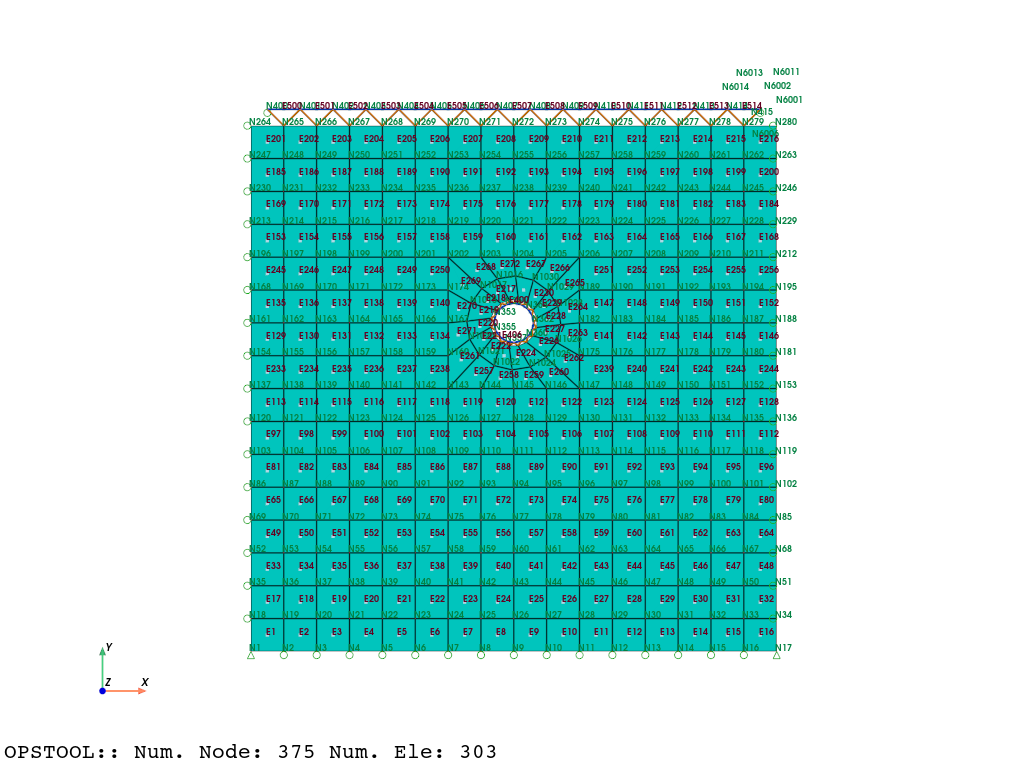

In [47]:
OPSVIS.set_plot_props(point_size=1, font_size=9, notebook=True)
OPSVIS.plot_model(show_node_numbering=True, show_ele_numbering=True).show(jupyter_backend="jupyterlab")

In [48]:
ODB = opst.post.CreateODB(
    odb_tag=1,
    model_update=True,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",
)

In [49]:
# define analysis parameters for gravity phase
ops.constraints("Transformation")
ops.test("NormDispIncr", 1e-05, 50, 0)
ops.algorithm("Newton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [50]:
# turn on initial state analysis feature
ops.InitialStateAnalysis("on")
# ensure soil material intially considers linear elastic behavior
ops.updateMaterialStage("-material", 1, "-stage", 0)
# set contact elements to be frictionless for gravity analysis
ops.setParameter("-val", 0, "-eleRange", 5000, 5015, "friction")
ops.setParameter("-val", 0, "-eleRange", 6000, 6014, "friction")
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()

InitialStateAnalysis ON


In [ ]:
# update soil material to consider elastoplastic behavior and analyze a few more steps
ops.updateMaterialStage("-material", 1, "-stage", 1)
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()
# designate end of initial state analysis (zeros displacements, keeps state variables)
ops.InitialStateAnalysis("off")
# turn on frictional behavior for beam contact elements
ops.setParameter("-val", 0, "-eleRange", 5000, 5015, "friction")
ops.setParameter("-val", 0, "-eleRange", 6000, 6014, "friction")

In [ ]:
# define analysis parameters for excavation phase
ops.wipeAnalysis()
ops.constraints("Transformation")
ops.test("NormDispIncr", 0.0001, 60)
ops.algorithm("KrylovNewton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [ ]:
def remove_components(ele_tags, node_tags, nsteps=4):
    for etag in ele_tags:
        ops.remove("element", etag)
    for ntag in node_tags:
        ops.remove("node", ntag)
    # run analysis after object removal
    for _ in range(nsteps):
        ops.analyze(1)
        ODB.fetch_response_step()

In [ ]:
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)
ops.load(350, 0, -1 ,0)

In [ ]:
ops.analyze(1)

after: 60 iterations  current Norm: 0.238244 (max: 0.0001, Norm deltaR: 4.48905)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 1
OpenSees > analyze failed, returned: -3 error flag


-3

In [92]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 1 removed")

after: 60 iterations  current Norm: 1.17578 (max: 0.0001, Norm deltaR: 42.1859)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 1
OpenSees > analyze failed, returned: -3 error flag
after: 60 iterations  current Norm: 1.17578 (max: 0.0001, Norm deltaR: 42.1859)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 1
OpenSees > analyze failed, returned: -3 error flag
after: 60 iterations  current Norm: 1.17578 (max: 0.0001, Norm deltaR: 42.1859)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 1
OpenSees > analyze failed, returned: -3 error flag


Lift 1 removed


after: 60 iterations  current Norm: 1.17578 (max: 0.0001, Norm deltaR: 42.1859)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 1
OpenSees > analyze failed, returned: -3 error flag


In [93]:
ops.load(268, 0, -20*UNIT.kN)

In [94]:
ops.analyze(1)

after: 60 iterations  current Norm: 0.217098 (max: 0.0001, Norm deltaR: 74.7427)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 1
OpenSees > analyze failed, returned: -3 error flag


-3

In [89]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 2 removed")

Lift 2 removed


In [90]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=True, show_nodal_loads = True)

In [91]:
ODB.save_response(zlib=True)

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [92]:
import matplotlib.pyplot as plt

import opstool as opst
import opstool.vis.pyvista as opsvis

In [93]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

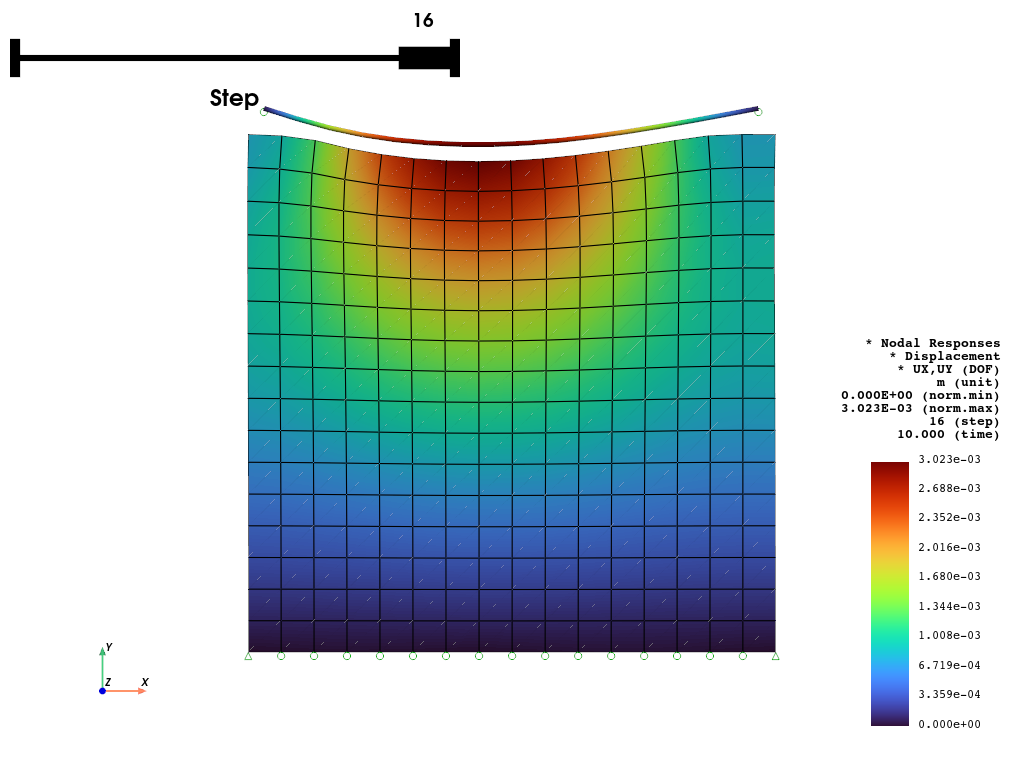

In [94]:
opsvis.plot_nodal_responses(
    odb_tag=1,
    slides=True,
    scale=2,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="juoyterlab")

In [95]:
opsvis.plot_nodal_responses_animation(
    odb_tag=1,
    framerate=2,
    scale=2,
    savefig="NodalRespAnimationA.gif",
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved to NodalRespAnimationA.gif!


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

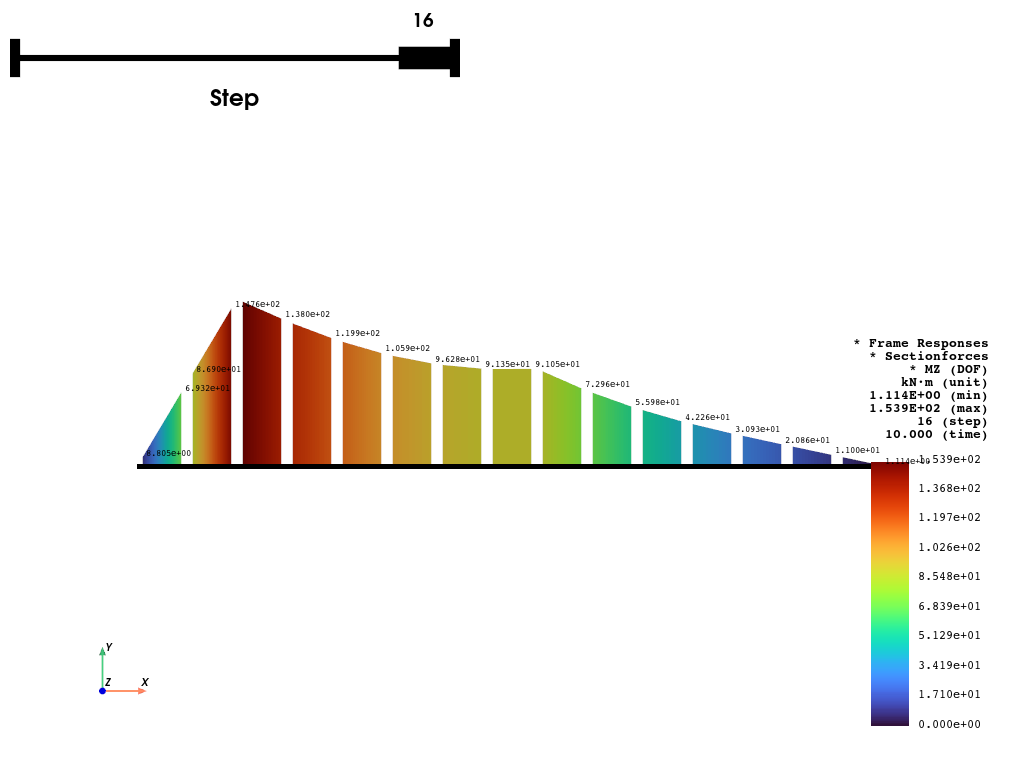

In [96]:
plotter = opsvis.plot_frame_responses(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    unit_symbol="kN·m",
    show_values="eleMaxMin",
    scale=3,
    slides=True,
    style="surface",
    show_model=False,  # plot all model
    opacity=1.0,
    show_bc=False,
)
plotter.show(jupyter_backend="jupyterlab")

In [97]:
opsvis.plot_frame_responses_animation(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    framerate=2,
    scale=3,
    line_width=4,
    savefig="FrameForcesMZ_A.gif",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved as FrameForcesMZ_A.gif!


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

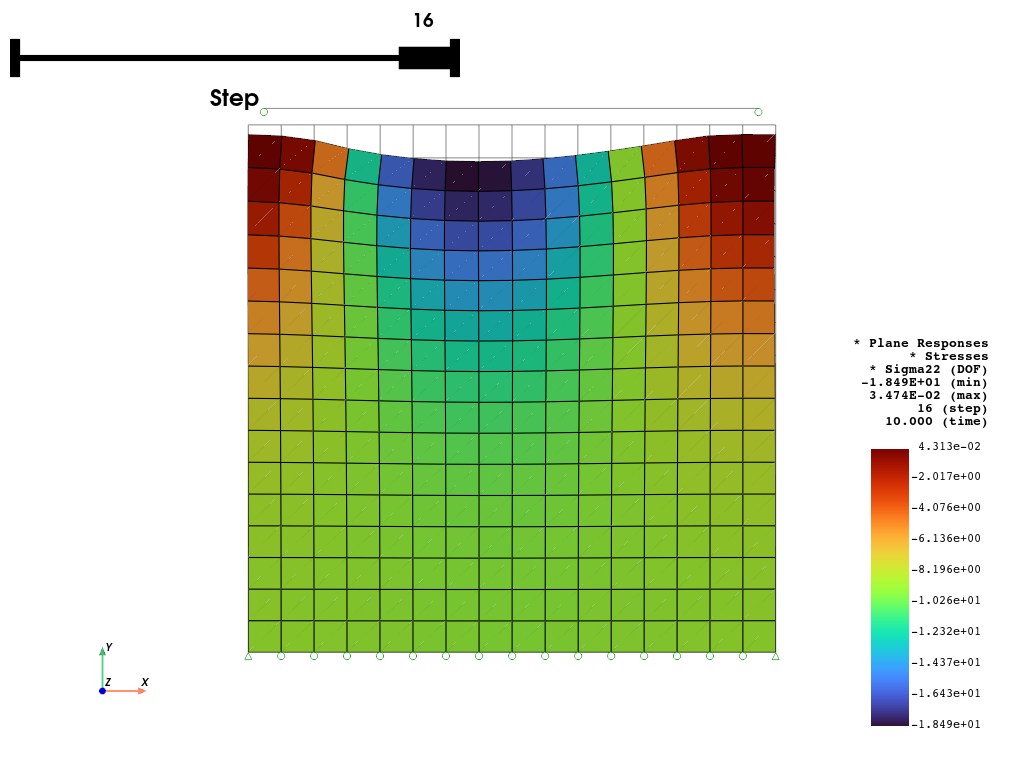

In [98]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma22"
).show(jupyter_backend="jupyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

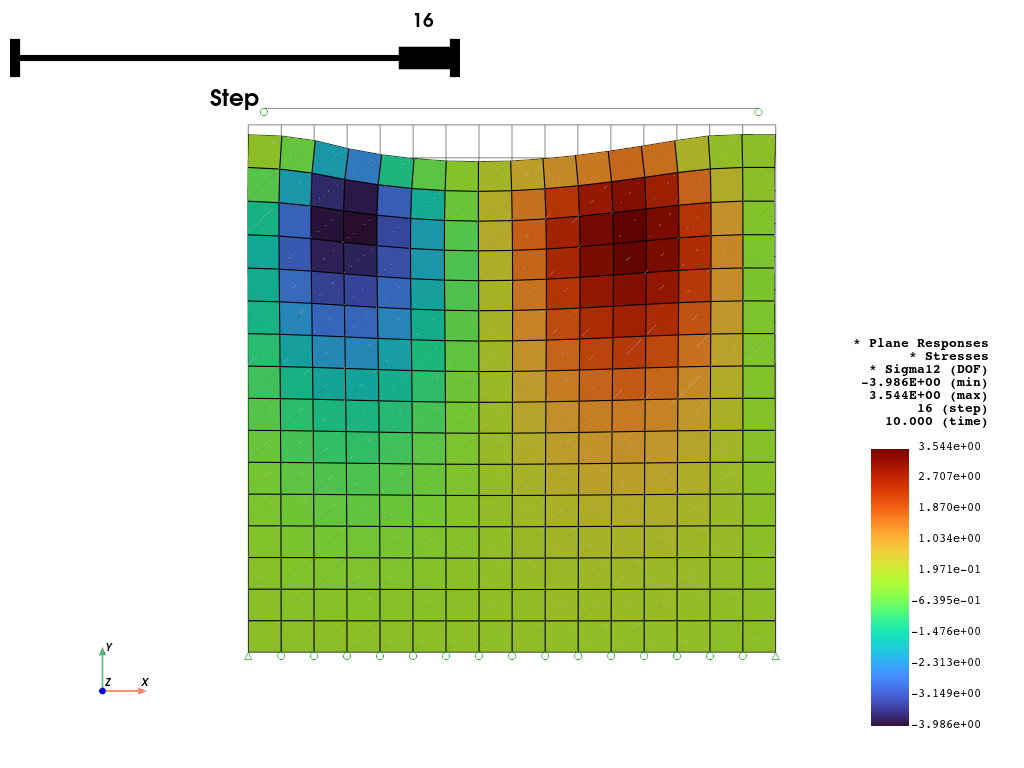

In [99]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma12"
).show(jupyter_backend="jupyterlab")

In [100]:
data = opst.post.get_element_responses(odb_tag=1, ele_type="Contact")

OPSTOOL ::  Loading Contact response data from .opstool.output/RespStepData-1.nc ...

In [101]:
print(data)

<xarray.Dataset> Size: 12kB
Dimensions:       (time: 17, eleTags: 15, globalDOFs: 3, localDOFs: 3,
                   slipDOFs: 2)
Coordinates:
  * eleTags       (eleTags) int64 120B 3050 3051 3052 3053 ... 3062 3063 3064
  * globalDOFs    (globalDOFs) <U2 24B 'Px' 'Py' 'Pz'
  * localDOFs     (localDOFs) <U2 24B 'N' 'Tx' 'Ty'
  * slipDOFs      (slipDOFs) <U2 16B 'Tx' 'Ty'
  * time          (time) float64 136B 0.0 1.0 2.0 3.0 4.0 ... 7.0 8.0 9.0 10.0
Data variables:
    globalForces  (time, eleTags, globalDOFs) float32 3kB -0.0 -0.0 ... -0.0 0.0
    localForces   (time, eleTags, localDOFs) float32 3kB 0.0 0.0 0.0 ... 0.0 0.0
    localDisp     (time, eleTags, localDOFs) float32 3kB 0.0 0.0 0.0 ... 0.0 0.0
    slips         (time, eleTags, slipDOFs) float32 2kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    Px:       Global force in the x-direction on the constrained node
    Py:       Global force in the y-direction on the constrained node
    Pz:       Global force in the z-direction on the co

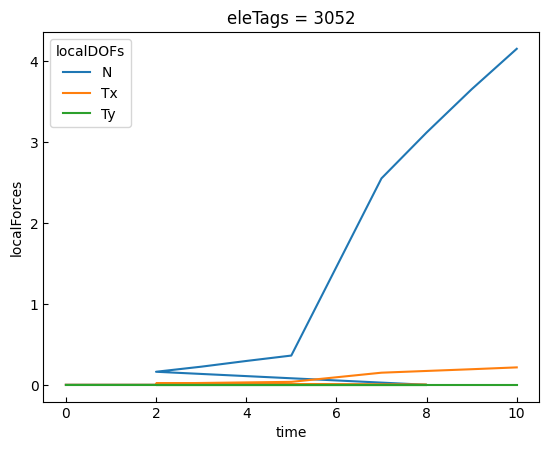

In [102]:
data["localForces"].sel(eleTags=3052).plot.line(x="time")
plt.show()

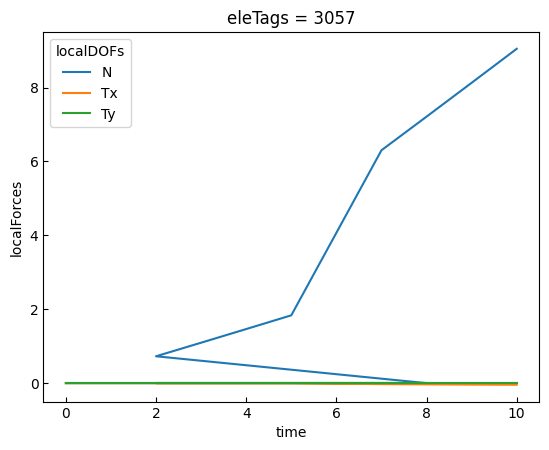

In [103]:
data["localForces"].sel(eleTags=3057).plot.line(x="time")
plt.show()

In [104]:
data["localForces"].sel(eleTags=3057).data

array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 7.2723317e-01,  8.8368164e-04,  0.0000000e+00],
       [ 1.0944721e+00,  1.3355352e-03,  0.0000000e+00],
       [ 1.4638366e+00,  1.7616540e-03,  0.0000000e+00],
       [ 1.8354239e+00,  2.2243743e-03,  0.0000000e+00],
       [ 6.3021312e+00, -2.6574787e-02,  0.0000000e+00],
       [ 7.2117262e+00, -3.3400644e-02,  0.0000000e+00],
       [ 8.1276951e+00, -3.9755881e-02,  0.0000000e+00],
       [ 9.0476866e+00, -4.4229850e-02,  0.0000000e+00]], dtype=float32)

In [105]:
data["localDisp"].sel(eleTags=3057).data

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)

In [106]:
data_frame = opst.post.get_element_responses(odb_tag=1, ele_type="Frame")

OPSTOOL ::  Loading Frame response data from .opstool.output/RespStepData-1.nc ...

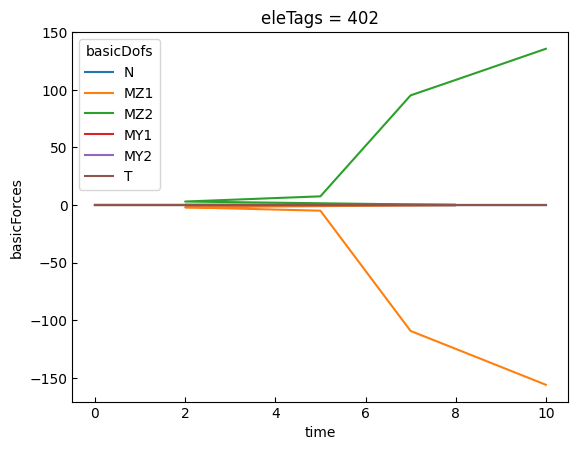

In [107]:
data_frame["basicForces"].sel(eleTags=402).plot.line(x="time")
plt.show()

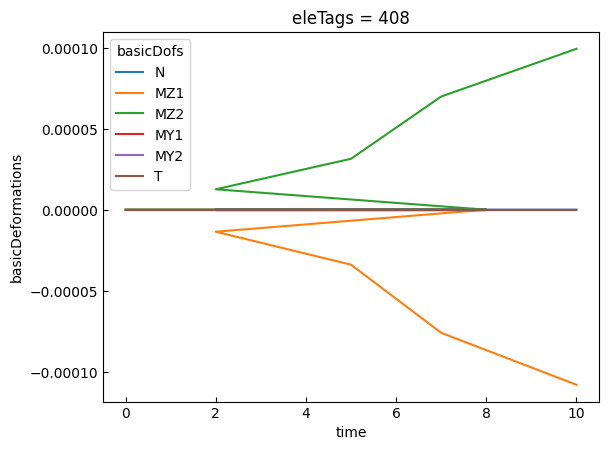

In [108]:
data_frame["basicDeformations"].sel(eleTags=408).plot.line(x="time")
plt.show()